# Notebook 03 — Feature Engineering
**CMPE-255 | Mental Health & Crisis Signal Mining** | **Owner: Ravikumar Komandur Narayanan** | **Colab / Local**

---

### Dataset
**Sentiment Analysis for Mental Health (Sarkar)** — 7-class classification
([Kaggle](https://www.kaggle.com/datasets/suchintikasarkar/sentiment-analysis-for-mental-health))

Classes: Anxiety, Bipolar, Depression, Normal, Personality disorder, Stress, Suicidal

### What this notebook produces

| Artifact | Location | Description |
|---|---|---|
| `tfidf_vectorizer.joblib` | `artifacts/` | TF-IDF vectorizer fit on training set only |
| `X_train_tfidf.npz` | `artifacts/` | Sparse TF-IDF matrix for training set |
| `X_test_tfidf.npz` | `artifacts/` | Sparse TF-IDF matrix for test set |
| `X_train_engineered.npz` | `artifacts/` | NRC emotion counts + surface stats (train) |
| `X_test_engineered.npz` | `artifacts/` | NRC emotion counts + surface stats (test) |
| `feature_names.json` | `artifacts/` | Human-readable feature name list |

### Three feature families

| Family | Dimensionality | Purpose |
|---|---|---|
| **TF-IDF** (unigrams + bigrams) | up to 50,000 | Primary lexical representation for LR, SVM, XGBoost |
| **NRC Emotion Lexicon counts** | 10 emotions | Captures emotional tone beyond word frequency |
| **Surface statistics** | 5 features | Word count, sentence count, punctuation density, capitalisation ratio, avg word length |

### Sprint 2 addition
After Notebook 07 (LDA Topic Modelling), set `USE_LDA_FEATURES = True` and re-run
this notebook to append LDA topic probability vectors to the engineered matrix.

In [ ]:
# nrclex provides the full NRC Emotion Lexicon (Mohammad & Turney, 2013).
# It is a freely-licensed list of ~14,000 English words annotated with 8 emotions + 2 sentiment polarities.
# We install it here and fall back to a seed-word dictionary if it is unavailable.
try:
    import nrclex
    print('nrclex already installed.')
except ImportError:
    !pip install nrclex --quiet
    print('nrclex installed.')
print('Packages ready.')

In [ ]:
# ============================================================
# CELL 3 — Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print('Google Drive mounted.')

In [ ]:
# ============================================================
# CELL 4 — Path Configuration
# ============================================================

from pathlib import Path

# ---------------------------------------------------------------------------
# Sprint 2 toggle: set to True AFTER running Notebook 07 (LDA Topic Modelling)
# ---------------------------------------------------------------------------
USE_LDA_FEATURES = False   # <-- flip to True after NB-07 is complete

# ---------------------------------------------------------------------------
# EDIT THIS ONE LINE to match your Google Drive folder name
# ---------------------------------------------------------------------------
DRIVE_ROOT = Path('/content/drive/MyDrive/CMPE255_Project')   # <-- change if needed

# Derived paths
DATA_DIR       = DRIVE_ROOT / 'data'
ARTIFACTS_DIR  = DRIVE_ROOT / 'artifacts'
FIGURES_DIR    = DRIVE_ROOT / 'figures'

for d in [DATA_DIR, ARTIFACTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# Data files — Jesigga's Sarkar-only 7-class train/test split
# ---------------------------------------------------------------------------
train_path = DATA_DIR / 'train.parquet'
test_path  = DATA_DIR / 'test.parquet'

print(f'DRIVE_ROOT       : {DRIVE_ROOT}')
print(f'DATA_DIR         : {DATA_DIR}')
print(f'ARTIFACTS_DIR    : {ARTIFACTS_DIR}')
print(f'USE_LDA_FEATURES : {USE_LDA_FEATURES}')
print()

print('Input file checks:')
print(f'  train.parquet  {"✅" if train_path.exists() else "❌ NOT FOUND"}')
print(f'  test.parquet   {"✅" if test_path.exists()  else "❌ NOT FOUND"}')

if USE_LDA_FEATURES:
    lda_path = ARTIFACTS_DIR / 'lda_topic_features.npz'
    print(f'  lda_topic_features.npz  {"✅" if lda_path.exists() else "❌ NOT FOUND — run NB-07 first"}')

if not train_path.exists() or not test_path.exists():
    raise FileNotFoundError(
        f'Files not found! Upload train.parquet and test.parquet to: {DATA_DIR}'
    )

In [5]:
import random, os, json, string, re
import numpy as np
import pandas as pd
import scipy.sparse
import matplotlib.pyplot as plt, seaborn as sns
import matplotlib
import joblib
import warnings
from sklearn.feature_extraction.text import TfidfVectorizer
warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('All imports successful.')

All imports successful.


In [ ]:
# ============================================================
# CELL 6 — Project Constants
# ------------------------------------------------------------
# Updated for 7-class Sarkar dataset.
# Labels in the parquet files are strings — we encode them to
# integers here for sklearn compatibility.
# ============================================================

RANDOM_SEED = 42

def seed_everything(seed=42):
    """Seed all random-number generators for full reproducibility."""
    import random, os
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

seed_everything(RANDOM_SEED)

# ---------------------------------------------------------------------------
# 7-class label mapping — Sarkar dataset
# Sorted alphabetically for consistent integer encoding.
# ---------------------------------------------------------------------------
CLASS_NAMES = [
    'Anxiety',
    'Bipolar',
    'Depression',
    'Normal',
    'Personality disorder',
    'Stress',
    'Suicidal',
]

# String label → integer index (for sklearn)
LABEL_TO_INT = {name: i for i, name in enumerate(CLASS_NAMES)}

# Integer index → string label (for plots and reports)
LABEL_MAP = {i: name for i, name in enumerate(CLASS_NAMES)}

print(f'RANDOM_SEED : {RANDOM_SEED}')
print(f'CLASS_NAMES : {CLASS_NAMES}')
print(f'LABEL_TO_INT: {LABEL_TO_INT}')

## 1. Load Train/Test Parquets

The train/test split parquets were created by Notebook 02 (Data Preprocessing)
using the **Sarkar Sentiment Analysis for Mental Health** Kaggle dataset
([link](https://www.kaggle.com/datasets/suchintikasarkar/sentiment-analysis-for-mental-health)).

Each parquet contains:
- `statement` column — cleaned post text
- `label` column — string label (one of 7 classes)

Labels are encoded to integers (0–6) in this cell for sklearn compatibility.

In [ ]:
# ============================================================
# CELL 8 — Load Train/Test Parquets
# ------------------------------------------------------------
# Reads the deduplicated, leakage-free parquet files.
# Text column: 'statement'
# Label column: 'label' (string) → encoded to integers
# ============================================================

df_train = pd.read_parquet(train_path)
df_test  = pd.read_parquet(test_path)

print(f'Train shape: {df_train.shape}')
print(f'Test  shape: {df_test.shape}')
print(f'Columns    : {list(df_train.columns)}')
print()

# ---------------------------------------------------------------------------
# Extract text and labels
# ---------------------------------------------------------------------------
TEXT_COL  = 'statement'
LABEL_COL = 'label'

X_train_text = df_train[TEXT_COL].fillna('').tolist()
X_test_text  = df_test[TEXT_COL].fillna('').tolist()

# Encode string labels → integers using LABEL_TO_INT
y_train = df_train[LABEL_COL].map(LABEL_TO_INT).values
y_test  = df_test[LABEL_COL].map(LABEL_TO_INT).values

# Verify no unmapped labels (NaN would indicate a label not in LABEL_TO_INT)
assert not np.isnan(y_train).any(), f'Unmapped labels in train: {df_train[LABEL_COL].unique()}'
assert not np.isnan(y_test).any(),  f'Unmapped labels in test: {df_test[LABEL_COL].unique()}'

y_train = y_train.astype(int)
y_test  = y_test.astype(int)

print(f'X_train_text length : {len(X_train_text)}')
print(f'X_test_text  length : {len(X_test_text)}')
print(f'y_train shape       : {y_train.shape}  (range: {y_train.min()}–{y_train.max()})')
print(f'y_test  shape       : {y_test.shape}  (range: {y_test.min()}–{y_test.max()})')
print()

# ---------------------------------------------------------------------------
# Class distribution table
# ---------------------------------------------------------------------------
train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts  = pd.Series(y_test).value_counts().sort_index()

dist_df = pd.DataFrame({
    'Class Name'  : [LABEL_MAP[i] for i in train_counts.index],
    'Train Count' : train_counts.values,
    'Train %'     : (train_counts.values / len(y_train) * 100).round(1),
    'Test Count'  : test_counts.values,
    'Test %'      : (test_counts.values / len(y_test) * 100).round(1),
})
print('Class distribution:')
print(dist_df.to_string(index=False))
print()

print('First 3 rows of df_train:')
print(df_train.head(3).to_string())

## 2. TF-IDF Vectorization

### Why TF-IDF?
TF-IDF (Term Frequency–Inverse Document Frequency) is a classic and still highly competitive
baseline for text classification. It encodes two complementary signals:

- **TF (term frequency)**: how often a word appears in a given document — captures local word importance.
- **IDF (inverse document frequency)**: downweights words that appear in many documents
  (e.g. "the", "is", "a"), so that rare, discriminative words receive higher weight.

### Key hyperparameter choices

| Parameter | Value | Reason |
|---|---|---|
| `sublinear_tf=True` | `True` | Uses `log(1 + tf)` instead of raw `tf`, dampening the effect of extremely frequent tokens within a single post |
| `max_features` | 50,000 | Vocabulary cap keeps the matrix tractable in memory and avoids overfitting to very rare tokens |
| `min_df` | 2 | Ignores tokens appearing in fewer than 2 documents — these are likely typos, usernames, or random noise |
| `ngram_range` | `(1, 2)` | Includes both single words (unigrams) and two-word phrases (bigrams) to capture clinically meaningful phrases like "panic attack", "mood swing", "suicidal thoughts" |
| `token_pattern` | `r'(?u)\b[a-zA-Z][a-zA-Z0-9]+\b'` | Requires tokens to start with a letter and be at least 2 characters long — filters out standalone punctuation and numbers |

### Critical: fit on training set ONLY
The vectorizer is **fit** only on `X_train_text` and then **transformed** on both train and test.
Fitting on the test set would introduce **data leakage**: the vocabulary and IDF weights would
incorporate information about test-set word frequencies, making evaluation optimistically biased.

In [8]:
# ============================================================
# CELL 10 — Fit TF-IDF Vectorizer and Transform Splits
# ------------------------------------------------------------
# Fits the TF-IDF vocabulary on training data ONLY, then
# applies the same fixed vocabulary to the test set.
# Saves vectorizer (joblib) and matrices (.npz) to Drive.
# ============================================================

seed_everything(RANDOM_SEED)  # ensure reproducibility

# ---------------------------------------------------------------------------
# Define the TF-IDF vectorizer
# - ngram_range=(1,2)      : unigrams + bigrams
# - max_features=50_000    : vocabulary size cap
# - sublinear_tf=True      : log(1+tf) smoothing
# - min_df=2               : drop hapax legomena
# - strip_accents='unicode' : normalise accented chars (é → e)
# - analyzer='word'        : word-level tokenisation
# - token_pattern          : letters-only tokens of length >= 2
# ---------------------------------------------------------------------------
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50_000,
    sublinear_tf=True,
    min_df=2,
    strip_accents='unicode',
    analyzer='word',
    token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z0-9]+\b',
)

# ---------------------------------------------------------------------------
# Fit on training set ONLY, then transform both splits.
# fit_transform is slightly more efficient than fit then transform
# but semantically identical to the two-step version for the train set.
# ---------------------------------------------------------------------------
print('Fitting TF-IDF on training set...')
X_train_tfidf = tfidf.fit_transform(X_train_text)    # fit + transform (train)

print('Transforming test set (DO NOT refit!)...')
X_test_tfidf  = tfidf.transform(X_test_text)         # transform only (test)

# ---------------------------------------------------------------------------
# Diagnostics
# ---------------------------------------------------------------------------
vocab_size = len(tfidf.vocabulary_)
train_mem_mb = X_train_tfidf.data.nbytes / 1024**2
test_mem_mb  = X_test_tfidf.data.nbytes  / 1024**2

print(f'\nVocabulary size       : {vocab_size:,}')
print(f'X_train_tfidf shape   : {X_train_tfidf.shape}  ({train_mem_mb:.1f} MB stored values)')
print(f'X_test_tfidf  shape   : {X_test_tfidf.shape}   ({test_mem_mb:.1f} MB stored values)')
print()

# ---------------------------------------------------------------------------
# Save vectorizer with joblib (preferred over pickle: faster, safer)
# ---------------------------------------------------------------------------
vec_path = ARTIFACTS_DIR / 'tfidf_vectorizer.joblib'
joblib.dump(tfidf, vec_path)
print(f'Vectorizer saved  : {vec_path}')

# ---------------------------------------------------------------------------
# Save sparse matrices in .npz format
# scipy.sparse.save_npz preserves sparsity — vastly smaller than dense .npy
# ---------------------------------------------------------------------------
scipy.sparse.save_npz(ARTIFACTS_DIR / 'X_train_tfidf.npz', X_train_tfidf)
scipy.sparse.save_npz(ARTIFACTS_DIR / 'X_test_tfidf.npz',  X_test_tfidf)
print(f'X_train_tfidf saved: {ARTIFACTS_DIR / "X_train_tfidf.npz"}')
print(f'X_test_tfidf  saved: {ARTIFACTS_DIR / "X_test_tfidf.npz"}')
print()

# ---------------------------------------------------------------------------
# Top 20 tokens by IDF weight
# Highest IDF = rarest across the corpus = most discriminative
# ---------------------------------------------------------------------------
feature_names_arr = np.array(tfidf.get_feature_names_out())
idf_scores        = tfidf.idf_

top20_idx    = np.argsort(idf_scores)[::-1][:20]
top20_tokens = feature_names_arr[top20_idx]
top20_idf    = idf_scores[top20_idx]

print('Top 20 tokens by IDF weight (rarest / most discriminative):')
for tok, score in zip(top20_tokens, top20_idf):
    print(f'  {tok:<30}  IDF={score:.4f}')

Fitting TF-IDF on training set...
Transforming test set (DO NOT refit!)...

Vocabulary size       : 50,000
X_train_tfidf shape   : (3500, 50000)  (4.9 MB stored values)
X_test_tfidf  shape   : (876, 50000)   (1.2 MB stored values)

Vectorizer saved  : /content/drive/MyDrive/Guna_CMPE_255_Project/artifacts/tfidf_vectorizer.joblib
X_train_tfidf saved: /content/drive/MyDrive/Guna_CMPE_255_Project/artifacts/X_train_tfidf.npz
X_test_tfidf  saved: /content/drive/MyDrive/Guna_CMPE_255_Project/artifacts/X_test_tfidf.npz

Top 20 tokens by IDF weight (rarest / most discriminative):
  ability or                      IDF=8.0622
  aborted                         IDF=8.0622
  aborted me                      IDF=8.0622
  about about                     IDF=8.0622
  yrs old                         IDF=8.0622
  zap                             IDF=8.0622
  zero interest                   IDF=8.0622
  about lbs                       IDF=8.0622
  about past                      IDF=8.0622
  about quitting

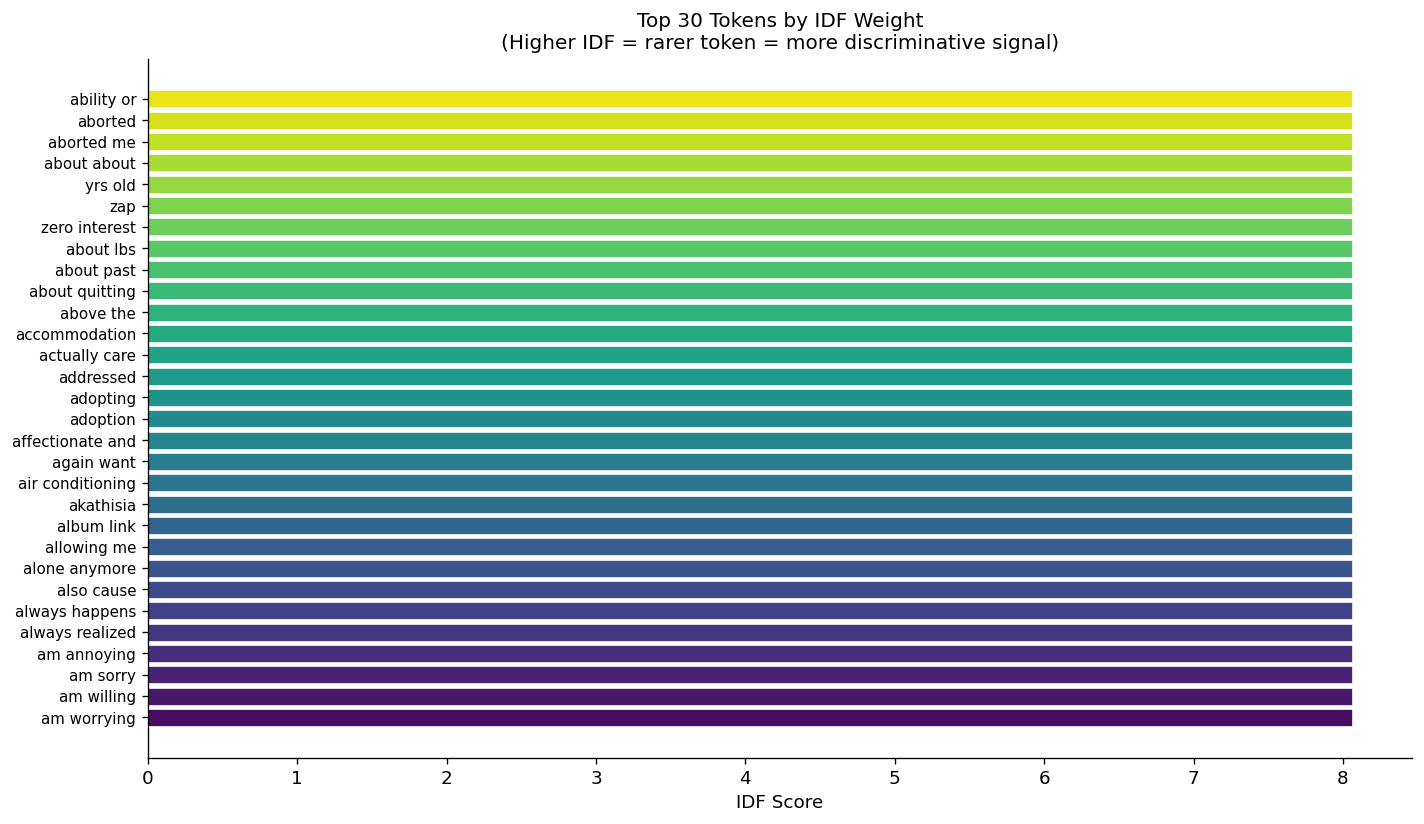

Figure saved: /content/drive/MyDrive/Guna_CMPE_255_Project/figures/tfidf_top_idf_tokens.png

Top 10 bigrams by IDF weight:
  abandoned my                         IDF=8.0622
  abandonment issues                   IDF=8.0622
  about lbs                            IDF=8.0622
  your work                            IDF=8.0622
  about past                           IDF=8.0622
  about quitting                       IDF=8.0622
  above the                            IDF=8.0622
  actually care                        IDF=8.0622
  affectionate and                     IDF=8.0622
  again want                           IDF=8.0622


In [9]:
# ============================================================
# CELL 11 — IDF Weight Visualisation
# ------------------------------------------------------------
# Bar chart of the top 30 tokens by IDF weight.
# High-IDF tokens are rare across the corpus and therefore
# carry the most discriminative signal for classification.
# Also prints top 10 bigrams (tokens containing a space).
# ============================================================

# ---------------------------------------------------------------------------
# Top 30 tokens by IDF weight — bar chart
# ---------------------------------------------------------------------------
top_n = 30
top_idx    = np.argsort(idf_scores)[::-1][:top_n]
top_tokens = feature_names_arr[top_idx]
top_idf    = idf_scores[top_idx]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(
    range(top_n), top_idf[::-1],   # reverse so highest is at top
    color=sns.color_palette('viridis', top_n),
    edgecolor='white', linewidth=0.4,
)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_tokens[::-1], fontsize=9)
ax.set_xlabel('IDF Score')
ax.set_title(
    f'Top {top_n} Tokens by IDF Weight\n'
    '(Higher IDF = rarer token = more discriminative signal)',
    fontsize=12,
)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

fig_path = FIGURES_DIR / 'tfidf_top_idf_tokens.png'
fig.savefig(fig_path, bbox_inches='tight')
plt.show()
print(f'Figure saved: {fig_path}')
print()

# ---------------------------------------------------------------------------
# Top 10 bigrams (features whose name contains a space)
# Bigrams are especially informative for clinical text —
# phrases like 'panic attack' or 'mood swing' carry meaning
# that unigrams alone cannot capture.
# ---------------------------------------------------------------------------
bigram_mask    = np.array([' ' in t for t in feature_names_arr])
bigram_tokens  = feature_names_arr[bigram_mask]
bigram_idf     = idf_scores[bigram_mask]

top10_bigram_idx = np.argsort(bigram_idf)[::-1][:10]
print('Top 10 bigrams by IDF weight:')
for tok, score in zip(bigram_tokens[top10_bigram_idx], bigram_idf[top10_bigram_idx]):
    print(f'  {tok:<35}  IDF={score:.4f}')

## 3. NRC Emotion Lexicon Features

### What is the NRC Emotion Lexicon?
The **NRC Word-Emotion Association Lexicon** (Mohammad & Turney, 2013) is a crowd-sourced list
of approximately 14,000 English words, each annotated with binary associations for:
- **8 basic emotions** from Plutchik's wheel: *anger, anticipation, disgust, fear, joy, sadness, surprise, trust*
- **2 sentiment polarities**: *positive, negative*

### Why this matters for mental health text
Different psychiatric conditions exhibit distinctive emotional profiles that TF-IDF alone
may not capture robustly:

| Condition | Expected dominant emotions |
|---|---|
| Depression | Elevated **sadness** + **negative** |
| Anxiety | Elevated **fear** + **negative** |
| Bipolar | Elevated **anticipation** + **joy** (manic phase); **sadness** (depressive phase) |
| Stress | Elevated **anger** + **fear** |
| Personality disorder | Mixed; often elevated **disgust** + **anger** |
| Suicidal | Elevated **sadness** + **negative** + **fear** |
| Normal | Elevated **positive** + **joy** + **trust** |

Emotion counts provide a **complementary signal** to TF-IDF: they are robust to paraphrasing
and capture affective tone that is otherwise distributed across many rare words.

### Implementation strategy
1. **Primary**: use the `nrclex` Python package, which wraps the full NRC lexicon.
2. **Fallback**: if `nrclex` is unavailable (import error), fall back to counting seed words
   from a hand-curated dictionary (`NRC_SEED_WORDS`) with ~10 representative words per category.

All counts are **normalised by document length** (number of words) to make them comparable
across posts of different lengths.

**Feature dimensionality**: 10 columns (one per emotion/sentiment category).

In [10]:
# ============================================================
# CELL 13 — NRC Emotion Feature Extraction Function
# ------------------------------------------------------------
# Defines get_nrc_features(texts) which returns a DataFrame
# with 10 emotion/sentiment columns per input text.
# Uses NRCLex if available; falls back to seed-word counting.
# ============================================================

# ---------------------------------------------------------------------------
# Seed-word fallback dictionary
# Used when the nrclex package cannot be imported.
# Each key is an emotion category; values are sets of representative words.
# These were chosen to span the semantic space of each emotion
# without heavy overlap between categories.
# ---------------------------------------------------------------------------
NRC_SEED_WORDS = {
    'anger':        {'angry','rage','fury','hatred','mad','furious','outrage','hostile','irritate','annoy'},
    'anticipation': {'expect','hope','eager','await','forward','anticipate','soon','ready','excite','plan'},
    'disgust':      {'disgust','gross','nasty','repulse','vile','awful','horrible','revolting','hate','sick'},
    'fear':         {'afraid','fear','scared','terror','panic','dread','horror','frighten','anxious','worry'},
    'joy':          {'happy','joy','love','wonderful','great','delight','cheerful','glad','bliss','smile'},
    'sadness':      {'sad','cry','grief','sorrow','tears','depressed','hopeless','miserable','alone','empty'},
    'surprise':     {'surprise','shock','amaze','astonish','sudden','unexpected','disbelief','wow','gasp','stun'},
    'trust':        {'trust','believe','faith','reliable','honest','safe','secure','confident','support','loyal'},
    'positive':     {'good','great','happy','wonderful','excellent','positive','nice','love','enjoy','perfect'},
    'negative':     {'bad','terrible','awful','horrible','wrong','pain','hurt','suffer','problem','struggle'},
}

# Canonical column order — always 10 features, always in this order
NRC_EMOTIONS = sorted(NRC_SEED_WORDS.keys())


def get_nrc_features(texts):
    """Compute NRC emotion feature vectors for a list of text strings.

    For each text, counts how many words match each of the 10 NRC
    emotion/sentiment categories, then normalises by total word count
    to produce a per-document emotion profile.

    Parameters
    ----------
    texts : list of str
        Raw or lightly pre-processed post texts.

    Returns
    -------
    pd.DataFrame
        Shape (len(texts), 10) with columns = NRC_EMOTIONS.
        Values are normalised counts in [0, 1].
    """
    # ------------------------------------------------------------------
    # Try to import NRCLex (full 14k-word lexicon)
    # ------------------------------------------------------------------
    try:
        from nrclex import NRCLex
        USE_NRCLEX = True
        print('  Using NRCLex (full lexicon ~14k words)')
    except ImportError:
        USE_NRCLEX = False
        print('  NRCLex not available — using seed-word fallback')

    records = []  # will hold one dict per text

    for text in texts:
        # Normalise text: lower-case for word matching
        clean = text.lower()
        # Tokenise by splitting on whitespace (simple but fast)
        words      = clean.split()
        word_count = max(len(words), 1)   # avoid division by zero

        row = {emotion: 0.0 for emotion in NRC_EMOTIONS}

        if USE_NRCLEX:
            # ------------------------------------------------------------------
            # NRCLex path: instantiate an NRCLex object on the text,
            # then read its .raw_emotion_scores dict which maps each emotion
            # to a raw integer count of matching words.
            # ------------------------------------------------------------------
            try:
                nrc_obj = NRCLex(clean)
                scores  = nrc_obj.raw_emotion_scores   # dict: {emotion: count}
                for emotion in NRC_EMOTIONS:
                    row[emotion] = scores.get(emotion, 0) / word_count
            except Exception:
                # If NRCLex fails on a specific text (e.g. empty string),
                # leave all emotions as 0.0 for this row
                pass
        else:
            # ------------------------------------------------------------------
            # Seed-word fallback path: count occurrences of each seed word
            # (after stripping punctuation from each token).
            # ------------------------------------------------------------------
            punct_table = str.maketrans('', '', string.punctuation)

            for emotion, seed_set in NRC_SEED_WORDS.items():
                # Count how many words in this post match the seed set
                count = sum(1 for w in words if w.translate(punct_table) in seed_set)
                row[emotion] = count / word_count

        records.append(row)

    # Return as a DataFrame with consistent column ordering
    return pd.DataFrame(records, columns=NRC_EMOTIONS)


print('get_nrc_features() defined.')
print(f'NRC emotion columns ({len(NRC_EMOTIONS)}): {NRC_EMOTIONS}')

get_nrc_features() defined.
NRC emotion columns (10): ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'negative', 'positive', 'sadness', 'surprise', 'trust']


In [ ]:
# ============================================================
# CELL 14 — Compute NRC Features for Train and Test Sets
# ------------------------------------------------------------
# Computes emotion feature vectors for both splits.
# Plots a heatmap of mean emotion scores per class —
# a key EDA figure showing each disorder's emotional signature.
# ============================================================

print('Computing NRC features for training set...')
nrc_train = get_nrc_features(X_train_text)

print('Computing NRC features for test set...')
nrc_test  = get_nrc_features(X_test_text)

print(f'\nnrc_train shape: {nrc_train.shape}')
print(f'nrc_test  shape: {nrc_test.shape}')
print()
print('nrc_train head(5):')
print(nrc_train.head(5).to_string())

# ---------------------------------------------------------------------------
# Heatmap: mean emotion score per class (train set)
# ---------------------------------------------------------------------------
nrc_train_labeled = nrc_train.copy()
nrc_train_labeled['class_name'] = [LABEL_MAP[y] for y in y_train]

nrc_mean_by_class = (
    nrc_train_labeled
    .groupby('class_name')[NRC_EMOTIONS]
    .mean()
    .reindex(CLASS_NAMES)   # consistent row order (7 classes)
)

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    nrc_mean_by_class,
    annot=True,
    fmt='.4f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Mean normalised count'},
)
ax.set_title(
    'Mean NRC Emotion Score per Mental Health Class (Train Set)\n'
    'Each cell = average fraction of words matching that emotion category',
    fontsize=12,
)
ax.set_xlabel('Emotion / Sentiment Category')
ax.set_ylabel('Mental Health Class')
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()

heatmap_path = FIGURES_DIR / 'nrc_emotion_by_class.png'
fig.savefig(heatmap_path, bbox_inches='tight')
plt.show()
print(f'Heatmap saved: {heatmap_path}')

## 4. Surface Statistics

Surface statistics capture **structural and stylistic properties** of each post
that are independent of vocabulary. They are fast to compute and provide orthogonal
signal to both TF-IDF and NRC emotion features.

### Feature descriptions

| Feature | Description | Clinical motivation |
|---|---|---|
| `word_count` | Total number of whitespace-separated tokens | Raw post length — longer posts often correlate with rumination (depression) or stream-of-consciousness writing |
| `sentence_count` | Approximate sentence count (split on `.`, `!`, `?`) | Structural complexity; highly fragmented or run-on writing can indicate certain conditions |
| `punct_density` | `n_punctuation_chars / total_chars` | Emotionally intense posts often contain more exclamation marks, ellipses, and question marks |
| `cap_ratio` | `n_uppercase_alpha / n_total_alpha` | ALL-CAPS words can signal emotional intensity, urgency, or elevated mood (associated with manic phases) |
| `avg_word_len` | Mean character length of words | Proxy for vocabulary sophistication; clinical/formal language tends to use longer words |

These 5 features are concatenated with the 10 NRC emotion features to form the
**15-dimensional engineered feature matrix** (`X_train_engineered.npz`).

In [12]:
# ============================================================
# CELL 16 — Surface Statistics Computation Function
# ------------------------------------------------------------
# Defines compute_surface_stats(texts) which returns a DataFrame
# with 5 structural/stylistic feature columns per input text.
# ============================================================

# Set of all punctuation characters (Python standard library)
PUNCT_SET = set(string.punctuation)


def compute_surface_stats(texts):
    """Compute 5 surface-level statistical features for each text.

    These features are computed directly from raw character and word
    sequences without any tokenisation model or lexicon lookup.

    Parameters
    ----------
    texts : list of str
        Input post texts (can be raw or lightly cleaned).

    Returns
    -------
    pd.DataFrame
        Shape (len(texts), 5) with columns:
        ['word_count', 'sentence_count', 'punct_density',
         'cap_ratio', 'avg_word_len']
    """
    # Regex pattern to split on sentence-ending punctuation
    # Splits on '.', '!', '?' followed by optional whitespace
    sentence_split_re = re.compile(r'[.!?]+')

    records = []

    for text in texts:
        # Ensure we have a string (guard against NaN or None)
        text = str(text) if text else ''

        # --- word_count ---------------------------------------------------
        # Simple whitespace split; preserves punctuation attached to words
        words = text.split()
        word_count = len(words)

        # --- sentence_count -----------------------------------------------
        # Approximate sentence count by splitting on .!? delimiters
        # Filter out empty strings produced by consecutive delimiters
        sentences      = [s.strip() for s in sentence_split_re.split(text) if s.strip()]
        sentence_count = max(len(sentences), 1)  # at least 1 to avoid zeros

        # --- punct_density ------------------------------------------------
        # Fraction of characters that are punctuation
        total_chars = max(len(text), 1)  # avoid division by zero
        n_punct     = sum(1 for ch in text if ch in PUNCT_SET)
        punct_density = n_punct / total_chars

        # --- cap_ratio ----------------------------------------------------
        # Fraction of alphabetic characters that are uppercase
        alpha_chars = [ch for ch in text if ch.isalpha()]
        n_alpha     = max(len(alpha_chars), 1)  # avoid division by zero
        n_upper     = sum(1 for ch in alpha_chars if ch.isupper())
        cap_ratio   = n_upper / n_alpha

        # --- avg_word_len -------------------------------------------------
        # Mean character length across all words
        # Words with zero length (edge case) are excluded from the mean
        word_lens    = [len(w) for w in words if len(w) > 0]
        avg_word_len = np.mean(word_lens) if word_lens else 0.0

        records.append({
            'word_count'    : float(word_count),
            'sentence_count': float(sentence_count),
            'punct_density' : punct_density,
            'cap_ratio'     : cap_ratio,
            'avg_word_len'  : avg_word_len,
        })

    return pd.DataFrame(records, columns=[
        'word_count', 'sentence_count', 'punct_density', 'cap_ratio', 'avg_word_len'
    ])


# Store column names for later use when building feature_names.json
SURFACE_COLS = ['word_count', 'sentence_count', 'punct_density', 'cap_ratio', 'avg_word_len']

print('compute_surface_stats() defined.')
print(f'Surface feature columns ({len(SURFACE_COLS)}): {SURFACE_COLS}')

compute_surface_stats() defined.
Surface feature columns (5): ['word_count', 'sentence_count', 'punct_density', 'cap_ratio', 'avg_word_len']


In [ ]:
# ============================================================
# CELL 17 — Compute Surface Stats and Visualise
# ============================================================

print('Computing surface statistics for training set...')
surface_train = compute_surface_stats(X_train_text)

print('Computing surface statistics for test set...')
surface_test  = compute_surface_stats(X_test_text)

print(f'\nsurface_train shape: {surface_train.shape}')
print(f'surface_test  shape: {surface_test.shape}')
print()

print('surface_train describe():')
print(surface_train.describe().round(4).to_string())
print()
print('surface_test describe():')
print(surface_test.describe().round(4).to_string())

# ---------------------------------------------------------------------------
# Box plots: distribution of each surface feature per class (train set)
# ---------------------------------------------------------------------------
surface_train_labeled = surface_train.copy()
surface_train_labeled['class_name'] = [LABEL_MAP[y] for y in y_train]

n_features = len(SURFACE_COLS)
fig, axes = plt.subplots(1, n_features, figsize=(4 * n_features, 5), sharey=False)

palette = sns.color_palette('Set2', len(CLASS_NAMES))

for ax, feat in zip(axes, SURFACE_COLS):
    sns.boxplot(
        data=surface_train_labeled,
        x='class_name',
        y=feat,
        palette=palette,
        order=CLASS_NAMES,
        fliersize=1,
        ax=ax,
    )
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Surface Statistics by Mental Health Class (Train Set)', fontsize=13, y=1.01)
plt.tight_layout()

surf_fig_path = FIGURES_DIR / 'surface_stats_by_class.png'
fig.savefig(surf_fig_path, bbox_inches='tight')
plt.show()
print(f'Figure saved: {surf_fig_path}')

## 5. Combine Engineered Features

We now horizontally stack the **NRC emotion features** (10 columns) and
**surface statistics** (5 columns) into a single dense NumPy array of shape
`(n_samples, 15)` per split.

This combined matrix is saved as a compressed `.npz` file under the key `arr_0`.
Downstream notebooks load it with:

```python
X_train_eng = np.load(ARTIFACTS_DIR / 'X_train_engineered.npz')['arr_0']
```

### Who uses this matrix?

| Notebook | How it uses the engineered features |
|---|---|
| NB-04 (Linear Probe) | Trains a logistic regression on engineered features only — isolates their standalone discriminative power |
| NB-05 (XGBoost) | Optionally concatenates engineered features with TF-IDF matrix for a richer feature set |
| NB-06 (Evaluation) | Loads pre-computed predictions from all models, including those trained on engineered features |

We use `np.savez_compressed` (rather than `np.save`) to reduce disk usage.

In [14]:
# ============================================================
# CELL 19 — Combine NRC + Surface Features and Save
# ------------------------------------------------------------
# Horizontally stacks NRC and surface arrays, saves as
# compressed .npz, and writes the feature name list to JSON.
# ============================================================

# ---------------------------------------------------------------------------
# Stack NRC (10 cols) + surface (5 cols) → (n_samples, 15) float32 arrays
# Using float32 instead of float64 halves memory usage with negligible
# precision loss for these normalised features.
# ---------------------------------------------------------------------------
X_train_engineered = np.hstack([
    nrc_train.values.astype(np.float32),      # shape: (n_train, 10)
    surface_train.values.astype(np.float32),  # shape: (n_train,  5)
])  # result shape: (n_train, 15)

X_test_engineered = np.hstack([
    nrc_test.values.astype(np.float32),
    surface_test.values.astype(np.float32),
])  # result shape: (n_test, 15)

print(f'X_train_engineered shape: {X_train_engineered.shape}')
print(f'X_test_engineered  shape: {X_test_engineered.shape}')
print()

# ---------------------------------------------------------------------------
# Save with np.savez_compressed under key 'arr_0'
# IMPORTANT: downstream notebooks load with np.load(path)['arr_0']
# ---------------------------------------------------------------------------
train_eng_path = ARTIFACTS_DIR / 'X_train_engineered.npz'
test_eng_path  = ARTIFACTS_DIR / 'X_test_engineered.npz'

np.savez_compressed(train_eng_path, arr_0=X_train_engineered)
np.savez_compressed(test_eng_path,  arr_0=X_test_engineered)

print(f'X_train_engineered saved: {train_eng_path}')
print(f'X_test_engineered  saved: {test_eng_path}')
print()

# ---------------------------------------------------------------------------
# Build and save the human-readable feature name list
# NRC columns come first (alphabetical, matching NRC_EMOTIONS order),
# then surface stat columns in their definition order.
# ---------------------------------------------------------------------------
feature_names = NRC_EMOTIONS + SURFACE_COLS   # list of 15 strings

feat_names_path = ARTIFACTS_DIR / 'feature_names.json'
with open(feat_names_path, 'w') as f:
    json.dump(feature_names, f, indent=2)

print(f'feature_names.json saved: {feat_names_path}')
print(f'Total engineered features (Sprint 1): {len(feature_names)}')
print(f'Feature names: {feature_names}')

X_train_engineered shape: (3500, 15)
X_test_engineered  shape: (876, 15)

X_train_engineered saved: /content/drive/MyDrive/Guna_CMPE_255_Project/artifacts/X_train_engineered.npz
X_test_engineered  saved: /content/drive/MyDrive/Guna_CMPE_255_Project/artifacts/X_test_engineered.npz

feature_names.json saved: /content/drive/MyDrive/Guna_CMPE_255_Project/artifacts/feature_names.json
Total engineered features (Sprint 1): 15
Feature names: ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'negative', 'positive', 'sadness', 'surprise', 'trust', 'word_count', 'sentence_count', 'punct_density', 'cap_ratio', 'avg_word_len']


## 6. Sprint 2 — LDA Topic Feature Placeholder

**This section is a Sprint 2 enhancement.** No action is required here during Sprint 1.

### How to activate
After completing **Notebook 07 (LDA Topic Modelling)**:

1. Confirm that `artifacts/lda_topic_features.npz` exists on Drive
   (Notebook 07 saves it under keys `X_train` and `X_test`).
2. Return to **Cell 4** of this notebook and flip:
   ```python
   USE_LDA_FEATURES = True
   ```
3. **Re-run the entire notebook from Cell 4 onwards** (`Runtime → Run after`).

### What will change
- Cell 21 (below) will load the LDA topic-probability matrix and append it to
  `X_train_engineered.npz` and `X_test_engineered.npz`.
- `feature_names.json` will be updated to include `lda_topic_0`, `lda_topic_1`, ... `lda_topic_K`.
- All downstream notebooks that load `X_*_engineered.npz` will automatically benefit
  from the expanded feature set without any other changes.

### Why LDA features are useful
LDA topic probabilities capture **latent thematic content** — the mixture of topics a post
discusses — which complements both the lexical (TF-IDF) and emotional (NRC) representations.
For example, a topic dominated by words like *medication*, *dosage*, *psychiatrist* might be
a strong signal distinguishing clinically-engaged users from those in acute crisis.

In [15]:
# ============================================================
# CELL 21 — LDA Topic Feature Integration (Sprint 2)
# ------------------------------------------------------------
# Set USE_LDA_FEATURES = True in Cell 4 AFTER running Notebook 07.
# This cell appends the per-post LDA topic probability vectors
# (shape: n_samples × K_topics) to the engineered feature matrix.
# ============================================================

LDA_PATH = ARTIFACTS_DIR / 'lda_topic_features.npz'

if USE_LDA_FEATURES and LDA_PATH.exists():
    # Load LDA features saved by Notebook 07
    lda_data    = np.load(LDA_PATH)
    lda_train   = lda_data['X_train']   # shape: (n_train, K_topics)
    lda_test    = lda_data['X_test']    # shape: (n_test,  K_topics)
    K = lda_train.shape[1]
    print(f'LDA features loaded: {K} topics')

    # Load existing engineered matrix and append LDA columns
    X_tr_eng = np.load(ARTIFACTS_DIR / 'X_train_engineered.npz')['arr_0']
    X_te_eng = np.load(ARTIFACTS_DIR / 'X_test_engineered.npz')['arr_0']

    X_tr_full = np.hstack([X_tr_eng, lda_train.astype(np.float32)])
    X_te_full = np.hstack([X_te_eng, lda_test.astype(np.float32)])

    # Save the augmented matrices (overwrite engineered files)
    np.savez_compressed(ARTIFACTS_DIR / 'X_train_engineered.npz', arr_0=X_tr_full)
    np.savez_compressed(ARTIFACTS_DIR / 'X_test_engineered.npz',  arr_0=X_te_full)

    # Update feature names JSON
    lda_feat_names = [f'lda_topic_{i}' for i in range(K)]
    with open(ARTIFACTS_DIR / 'feature_names.json') as f:
        existing_names = json.load(f)
    all_names = existing_names + lda_feat_names
    with open(ARTIFACTS_DIR / 'feature_names.json', 'w') as f:
        json.dump(all_names, f)

    print(f'Updated engineered matrices: {X_tr_full.shape}')
    print(f'Updated feature_names.json: {len(all_names)} total features')
elif USE_LDA_FEATURES and not LDA_PATH.exists():
    print('⚠️  USE_LDA_FEATURES=True but lda_topic_features.npz not found.')
    print('   Run Notebook 07 first.')
else:
    print('LDA features not yet added (USE_LDA_FEATURES=False).')
    print('Set USE_LDA_FEATURES=True in Cell 4 after running Notebook 07.')

LDA features not yet added (USE_LDA_FEATURES=False).
Set USE_LDA_FEATURES=True in Cell 4 after running Notebook 07.


## 7. Artifact Inventory

A final inventory of all files produced by this notebook.
Run the cell below after completion to verify all 6 artifacts were written successfully.

In [16]:
# ============================================================
# CELL 23 — Artifact Inventory
# ------------------------------------------------------------
# Prints a clean table showing all 6 expected artifacts:
# existence check (✅/❌), file size in KB, and shape info.
# ============================================================

# List of (artifact_filename, description) tuples
ARTIFACT_SPECS = [
    ('tfidf_vectorizer.joblib', 'TF-IDF vectorizer (fit on train only)'),
    ('X_train_tfidf.npz',       'Sparse TF-IDF matrix — training set'),
    ('X_test_tfidf.npz',        'Sparse TF-IDF matrix — test set'),
    ('X_train_engineered.npz',  'NRC + surface engineered features — train'),
    ('X_test_engineered.npz',   'NRC + surface engineered features — test'),
    ('feature_names.json',      'Human-readable feature name list'),
]

print(f'{"Artifact":<35} {"Status":<6} {"Size (KB)":>10}  {"Shape / Info"}')
print('-' * 90)

for fname, desc in ARTIFACT_SPECS:
    fpath = ARTIFACTS_DIR / fname

    if fpath.exists():
        status   = '✅'
        size_kb  = fpath.stat().st_size / 1024

        # Determine shape/info based on file type
        if fname.endswith('.npz'):
            try:
                if 'tfidf' in fname:
                    # Sparse matrix
                    mat        = scipy.sparse.load_npz(fpath)
                    shape_info = f'sparse {mat.shape}'
                else:
                    # Dense engineered matrix
                    arr        = np.load(fpath)['arr_0']
                    shape_info = f'dense  {arr.shape}'
            except Exception as e:
                shape_info = f'load error: {e}'

        elif fname.endswith('.joblib'):
            try:
                obj        = joblib.load(fpath)
                shape_info = f'vocab size {len(obj.vocabulary_):,}'
            except Exception as e:
                shape_info = f'load error: {e}'

        elif fname.endswith('.json'):
            try:
                with open(fpath) as jf:
                    names = json.load(jf)
                shape_info = f'{len(names)} feature names'
            except Exception as e:
                shape_info = f'load error: {e}'

        else:
            shape_info = '—'

    else:
        status     = '❌'
        size_kb    = 0.0
        shape_info = 'NOT FOUND'

    print(f'{fname:<35} {status:<6} {size_kb:>10.1f}  {shape_info}')

print()
print(f'All artifacts directory: {ARTIFACTS_DIR}')
print('Notebook 03 complete.')

Artifact                            Status  Size (KB)  Shape / Info
------------------------------------------------------------------------------------------
tfidf_vectorizer.joblib             ✅          1937.3  vocab size 50,000
X_train_tfidf.npz                   ✅          4860.3  sparse (3500, 50000)
X_test_tfidf.npz                    ✅          1154.6  sparse (876, 50000)
X_train_engineered.npz              ✅            43.3  dense  (3500, 15)
X_test_engineered.npz               ✅            11.9  dense  (876, 15)
feature_names.json                  ✅             0.2  15 feature names

All artifacts directory: /content/drive/MyDrive/Guna_CMPE_255_Project/artifacts
Notebook 03 complete.
